In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def leastSquares(X,Y):
    sigX = np.sum(X)
    sigY = np.sum(Y)
    xSq = X**2
    sigX2 = np.sum(xSq)
    sigXY = np.dot(X,Y)
    n = len(X)
    
    m = (n*sigXY - sigX*sigY)/(n*sigX2 - sigX**2)
    c = (sigY - m*sigX)/n
    
    return m,c

In [13]:
import random
m = 0.5
b = 0.2
x = np.arange(0,1,0.01)
y = m*x+b
for i in range(len(x)): 
    err = random.uniform(-1,1)
    y[i]+=err
a = np.vstack([x, np.ones(len(x))]).T

In [14]:
# Solve using least squares numpy
NPm, NPc = np.linalg.lstsq(a, y, rcond=None)[0]
print(f"Numpy Method Slope: {NPm}, Numpy Method Intercept: {NPc}")

Numpy Method Slope: 0.5280757457877188, Numpy Method Intercept: 0.1370739465614755


In [15]:
# Solve using diy least squares method

LSm, LSc = leastSquares(x,y)
print(f"DIY Method Slope: {LSm}, DIY Method Intercept: {LSc}")

DIY Method Slope: 0.528075745787719, DIY Method Intercept: 0.13707394656147542


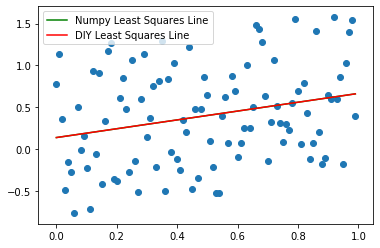

In [16]:
plt.scatter(x,y)
plt.plot(x,NPm*x+NPc,'g', label = "Numpy Least Squares Line")
plt.plot(x,LSm*x+LSc,'r', label = "DIY Least Squares Line")
plt.legend()
plt.show()

In [7]:
resid = LSm*x+LSc-y
print("residuals: ", resid)

residuals:  [-0.04490082 -0.45538207  0.49885211 -0.11590331  0.92008214 -0.7274418
 -0.67744198 -0.79648549  0.68637184  0.73050351 -0.43876286 -0.09810653
  0.4465733  -0.19621913  0.58510026  0.03888219  0.98423226  0.71378597
 -0.81329677 -0.80538569  0.27554285  0.96442089  0.04027747 -0.8535675
 -0.85184213  0.11363961  0.27380464 -0.46573692  0.65001072 -0.29232536
  0.80886226 -0.28969594 -0.70663166 -0.52388754  0.08273013 -0.31097804
  0.74583415  0.61482732  0.12873908 -0.64972512  0.14270954 -0.67593635
  0.43737825 -0.31837111 -0.99872909 -0.96086311 -0.12616569  0.86160802
  0.32016184  0.65247902 -0.56308452  0.78135146  0.59725532  0.46909486
  0.93788934 -0.06325222 -0.82654663 -0.60635545 -0.31266342  0.78358472
  0.29445055 -0.92505663 -0.13011077  0.40752418 -0.68480948 -0.97304316
 -0.24581394  0.24151327 -0.44182174  0.89406783 -0.9193307   0.56669809
  0.77580919 -0.1652806  -0.45753125  0.45881941 -0.53215728 -0.61995246
  0.02286576 -0.09414543  0.34934794  0.5

In [8]:
Lresid = np.argmax(resid)
Sresid = np.argmin(resid)

print("Largest residual: ",resid[Lresid], " at x = ",Lresid)
print("Smallest residual: ",resid[Sresid], " at x = ",Sresid)

Largest residual:  0.9842322597307096  at x =  16
Smallest residual:  -0.9987290876041743  at x =  44
